# Default Random Forest Classifier

Baseline notebook for training a `RandomForestClassifier` on `Tommy_Award_Player_Game_Table_hustle.csv` using the same setup as your decision tree notebook.

In [18]:

from pathlib import Path
import random

import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

csv_path = Path("Tommy_Award_Player_Game_Table_hustle.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Could not find dataset at: {csv_path.resolve()}")

df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns from {csv_path.name}")
df.head()

Loaded 8,530 rows and 60 columns from Tommy_Award_Player_Game_Table_hustle.csv


,gameId,teamId,teamCity,teamName,teamTricode,teamSlug,personId,firstName,familyName,nameI,...,assists_rank,steals_rank,blocks_rank,plusMinusPoints_rank,minutes_decimal_rank,deflections,deflections_missing,charges_drawn,charges_drawn_missing,usage_rate
0,21600006,1610612738,Boston,Celtics,BOS,celtics,203109,Jae,Crowder,J. Crowder,...,7.0,2.0,4.0,4.0,3.0,4.0,0,0.0,0,0.00227
1,21600006,1610612738,Boston,Celtics,BOS,celtics,101161,Amir,Johnson,A. Johnson,...,7.0,5.0,5.0,3.0,6.0,3.0,0,0.0,0,0.00185
2,21600006,1610612738,Boston,Celtics,BOS,celtics,201143,Al,Horford,A. Horford,...,2.0,8.0,1.0,2.0,5.0,1.0,0,0.0,0,0.00145
3,21600006,1610612738,Boston,Celtics,BOS,celtics,202340,Avery,Bradley,A. Bradley,...,2.0,5.0,5.0,4.0,1.0,4.0,0,0.0,0,0.00222
4,21600006,1610612738,Boston,Celtics,BOS,celtics,202738,Isaiah,Thomas,I. Thomas,...,1.0,2.0,5.0,1.0,2.0,2.0,0,0.0,0,0.00253


In [19]:
target_col = "y"
numeric_feature_cols = [
    "minutes_decimal",
    "points",
    "reboundsOffensive",
    "reboundsDefensive",
    "reboundsTotal",
    "assists",
    "steals",
    "blocks",
    "deflections",
    "charges_drawn",
    "turnovers",
    "foulsPersonal",
    "plusMinusPoints",
    "net_rating",
    "usage_rate",
    "impact_efficiency",
    "role_outperformance",
    "fieldGoalsMade",
    "fieldGoalsAttempted",
    "threePointersMade",
    "threePointersAttempted",
    "freeThrowsMade",
    "stocks",
    "points_per_min",
    "oreb_per_min",
    "reb_per_min",
    "ast_per_min",
    "stocks_per_min",
    "hustle_proxy",
    "points_rank",
    "reboundsOffensive_rank",
    "reboundsTotal_rank",
    "assists_rank",
    "steals_rank",
    "blocks_rank",
    "plusMinusPoints_rank",
    "minutes_decimal_rank",
    "stocks_rank",
    "hustle_proxy_rank",
]

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe.")

if "GAME_ID" in df.columns:
    game_id_col = "GAME_ID"
elif "gameId" in df.columns:
    game_id_col = "gameId"
else:
    raise ValueError("Could not find game id column (expected GAME_ID or gameId).")

if "game_date" in df.columns:
    df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce", format="mixed")

if "season" not in df.columns:
    if "game_date" not in df.columns:
        raise ValueError("Need either 'season' or 'game_date' to derive seasons.")
    start_year = df["game_date"].dt.year.where(df["game_date"].dt.month >= 10, df["game_date"].dt.year - 1)
    df["season"] = start_year.astype("Int64").astype(str) + "-" + (start_year + 1).astype("Int64").astype(str).str[-2:]

# Match the ridge/lasso and decision tree notebooks: only rows where a player logged minutes.
df = df[df["minutes_decimal"] > 0].copy()
mins = df["minutes_decimal"].clip(lower=1e-6)

# Recreate derived columns used by the shared feature list when missing.
if "net_rating" not in df.columns:
    df["net_rating"] = pd.to_numeric(df["plusMinusPoints"], errors="coerce")

if "stocks_per_min" not in df.columns:
    df["stocks_per_min"] = pd.to_numeric(df["stocks"], errors="coerce") / mins

eps = 1e-6
if "impact_efficiency" not in df.columns:
    df["impact_efficiency"] = pd.to_numeric(df["net_rating"], errors="coerce") / (pd.to_numeric(df["usage_rate"], errors="coerce") + eps)

if "role_outperformance" not in df.columns:
    df["role_outperformance"] = pd.to_numeric(df["net_rating"], errors="coerce") * (1 - pd.to_numeric(df["usage_rate"], errors="coerce"))

if "stocks_rank" not in df.columns:
    df["stocks_rank"] = df.groupby(game_id_col)["stocks"].rank(method="min", ascending=False)

if "hustle_proxy_rank" not in df.columns:
    df["hustle_proxy_rank"] = df.groupby(game_id_col)["hustle_proxy"].rank(method="min", ascending=False)

missing_cols = [col for col in numeric_feature_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing feature columns: {missing_cols}")

X = df[numeric_feature_cols].copy()
y = df[target_col].astype(int)

print(f"Rows after minutes filter: {len(df):,}")
print(f"Numeric features: {len(numeric_feature_cols)}")
print(f"Target vector shape: {y.shape}")

Rows after minutes filter: 8,495
Numeric features: 39
Target vector shape: (8495,)


In [20]:
requested_test_seasons = ["2024-25", "2025-26"]
available_seasons = sorted(df["season"].dropna().astype(str).unique().tolist())
selected_test_seasons = [s for s in requested_test_seasons if s in available_seasons]

if not selected_test_seasons:
    raise ValueError(
        f"None of the requested test seasons were found. Requested={requested_test_seasons}, available={available_seasons}"
    )

train_df = df[~df["season"].isin(selected_test_seasons)].copy()
test_df = df[df["season"].isin(selected_test_seasons)].copy()

X_train = train_df[numeric_feature_cols].copy()
X_test = test_df[numeric_feature_cols].copy()
y_train = train_df[target_col].astype(int)
y_test = test_df[target_col].astype(int)

summary_df = pd.DataFrame(
    {
        "item": [
            "rows",
            "numeric_features",
            "categorical_features",
            "train_games",
            "test_games",
            "train_positive_rate",
            "test_seasons",
            "models",
        ],
        "value": [
            len(df),
            len(numeric_feature_cols),
            0,
            train_df[game_id_col].nunique(),
            test_df[game_id_col].nunique(),
            round(train_df[target_col].mean(), 4),
            ", ".join(selected_test_seasons),
            "random_forest_optuna_tuned",
        ],
    }
)

display(summary_df)

,item,value
0,rows,8495
1,numeric_features,39
2,categorical_features,0
3,train_games,626
4,test_games,163
5,train_positive_rate,0.0927
6,test_seasons,"2024-25, 2025-26"
7,models,random_forest_optuna_tuned


In [21]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score

OPTUNA_TRIALS = 25
OPTUNA_TIMEOUT_SECONDS = 300
RANDOM_STATE = SEED


def sort_seasons(seasons: list[str]) -> list[str]:
    return sorted(seasons, key=lambda s: int(str(s).split("-")[0]))


def score_game_top1(scored: pd.DataFrame) -> float:
    winner_idx_local = scored.groupby(game_id_col)["pred_prob"].idxmax()
    score = float(scored.loc[winner_idx_local, target_col].mean())
    return 0.0 if pd.isna(score) else score


# Temporal validation split inside training data:
# - inner train: earlier seasons
# - val: latest season in train_df
train_seasons = sort_seasons(train_df["season"].dropna().astype(str).unique().tolist())
if len(train_seasons) < 2:
    raise ValueError("Need at least 2 train seasons for Optuna temporal validation.")

val_season = train_seasons[-1]
inner_train_df = train_df[train_df["season"].isin(train_seasons[:-1])].copy()
val_df = train_df[train_df["season"] == val_season].copy()

X_inner_train = inner_train_df[numeric_feature_cols].fillna(inner_train_df[numeric_feature_cols].median())
y_inner_train = inner_train_df[target_col].astype(int)
X_val = val_df[numeric_feature_cols].fillna(inner_train_df[numeric_feature_cols].median())


def objective(trial: optuna.trial.Trial) -> float:
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    max_samples = trial.suggest_float("max_samples", 0.5, 1.0) if bootstrap else None

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "max_depth": trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 80),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": bootstrap,
        "max_samples": max_samples,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    try:
        candidate = RandomForestClassifier(**params)
        candidate.fit(X_inner_train, y_inner_train)

        val_scored = val_df.copy()
        val_scored["pred_prob"] = candidate.predict_proba(X_val)[:, 1]
        return score_game_top1(val_scored)
    except ValueError:
        return 0.0


sampler = TPESampler(seed=RANDOM_STATE)
pruner = MedianPruner(n_startup_trials=5)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(
    objective,
    n_trials=OPTUNA_TRIALS,
    timeout=OPTUNA_TIMEOUT_SECONDS,
    gc_after_trial=True,
    show_progress_bar=True,
)

best_rf_params = {
    **study.best_params,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

# Ensure max_samples is explicit when bootstrap=False.
if not best_rf_params.get("bootstrap", True):
    best_rf_params["max_samples"] = None

model = RandomForestClassifier(**best_rf_params)
model.fit(X_train.fillna(X_train.median()), y_train)

# Score rows and convert probabilities to one predicted winner per game (top-1).
scored_df = test_df.copy()
scored_df["pred_prob"] = model.predict_proba(X_test.fillna(X_train.median()))[:, 1]
winner_idx = scored_df.groupby(game_id_col)["pred_prob"].idxmax()
y_pred_top1 = pd.Series(0, index=scored_df.index, dtype=int)
y_pred_top1.loc[winner_idx] = 1

metrics_df = pd.DataFrame(
    [
        {
            "game_top1_accuracy": scored_df.loc[winner_idx, target_col].mean(),
            "row_f1": f1_score(y_test, y_pred_top1, zero_division=0),
            "row_recall": recall_score(y_test, y_pred_top1, zero_division=0),
            "row_prauc": average_precision_score(y_test, scored_df["pred_prob"]),
            "row_precision": precision_score(y_test, y_pred_top1, zero_division=0),
        }
    ]
)

feature_importance_df = (
    pd.DataFrame({"feature": numeric_feature_cols, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Best Optuna validation game_top1_accuracy ({val_season}): {study.best_value:.4f}")
print("Best random forest hyperparameters:")
display(pd.DataFrame([best_rf_params]))

print("Random forest metrics on test seasons:")
display(metrics_df)

print("Top 15 feature importances:")
display(feature_importance_df.head(15))

[I 2026-04-14 21:21:49,297] A new study created in memory with name: no-name-27d86840-0faf-4d75-930d-c484c0cdcff3


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-14 21:21:51,040] Trial 0 finished with value: 0.34177215189873417 and parameters: {'bootstrap': False, 'n_estimators': 406, 'max_depth': 14, 'min_samples_split': 14, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.34177215189873417.
[I 2026-04-14 21:21:53,017] Trial 1 finished with value: 0.35443037974683544 and parameters: {'bootstrap': True, 'max_samples': 0.9849549260809971, 'n_estimators': 442, 'max_depth': 7, 'min_samples_split': 16, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 1 with value: 0.35443037974683544.
[I 2026-04-14 21:21:53,969] Trial 2 finished with value: 0.34177215189873417 and parameters: {'bootstrap': False, 'n_estimators': 198, 'max_depth': 8, 'min_samples_split': 30, 'min_samples_leaf': 14, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.35443037974683544.
[I 2026-04-14 21:21:54,773] Trial 3 finished with value: 0.3291139240506329 and parameters: {'bootstrap': True, 'max_samples': 0.8037724259507192

,bootstrap,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,random_state,n_jobs,max_samples
0,False,286,8,67,11,log2,42,-1,None


Random forest metrics on test seasons:


,game_top1_accuracy,row_f1,row_recall,row_prauc,row_precision
0,0.411043,0.411043,0.411043,0.357025,0.411043


Top 15 feature importances:


,feature,importance
0,fieldGoalsMade,0.138577
1,points,0.129429
2,points_per_min,0.101762
3,points_rank,0.080340
4,threePointersMade,0.055337
5,fieldGoalsAttempted,0.047730
6,hustle_proxy,0.034373
7,minutes_decimal,0.032074
8,plusMinusPoints_rank,0.025605
9,usage_rate,0.024326


Confusion Matrix (Top-1 per game):
[[1480   96]
 [  96   67]]


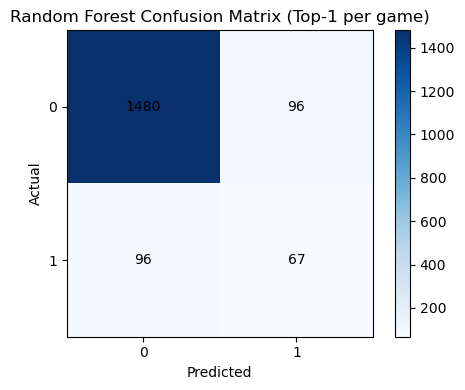

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Evaluate with the same top-1-per-game prediction logic used in metrics_df.
y_pred_top1_for_cm = pd.Series(0, index=scored_df.index, dtype=int)
y_pred_top1_for_cm.loc[winner_idx] = 1

print("Confusion Matrix (Top-1 per game):")
cm = confusion_matrix(y_test, y_pred_top1_for_cm)
print(cm)

try:
    import seaborn as sns

    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title("Random Forest Confusion Matrix (Top-1 per game)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
except ModuleNotFoundError:
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title("Random Forest Confusion Matrix (Top-1 per game)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

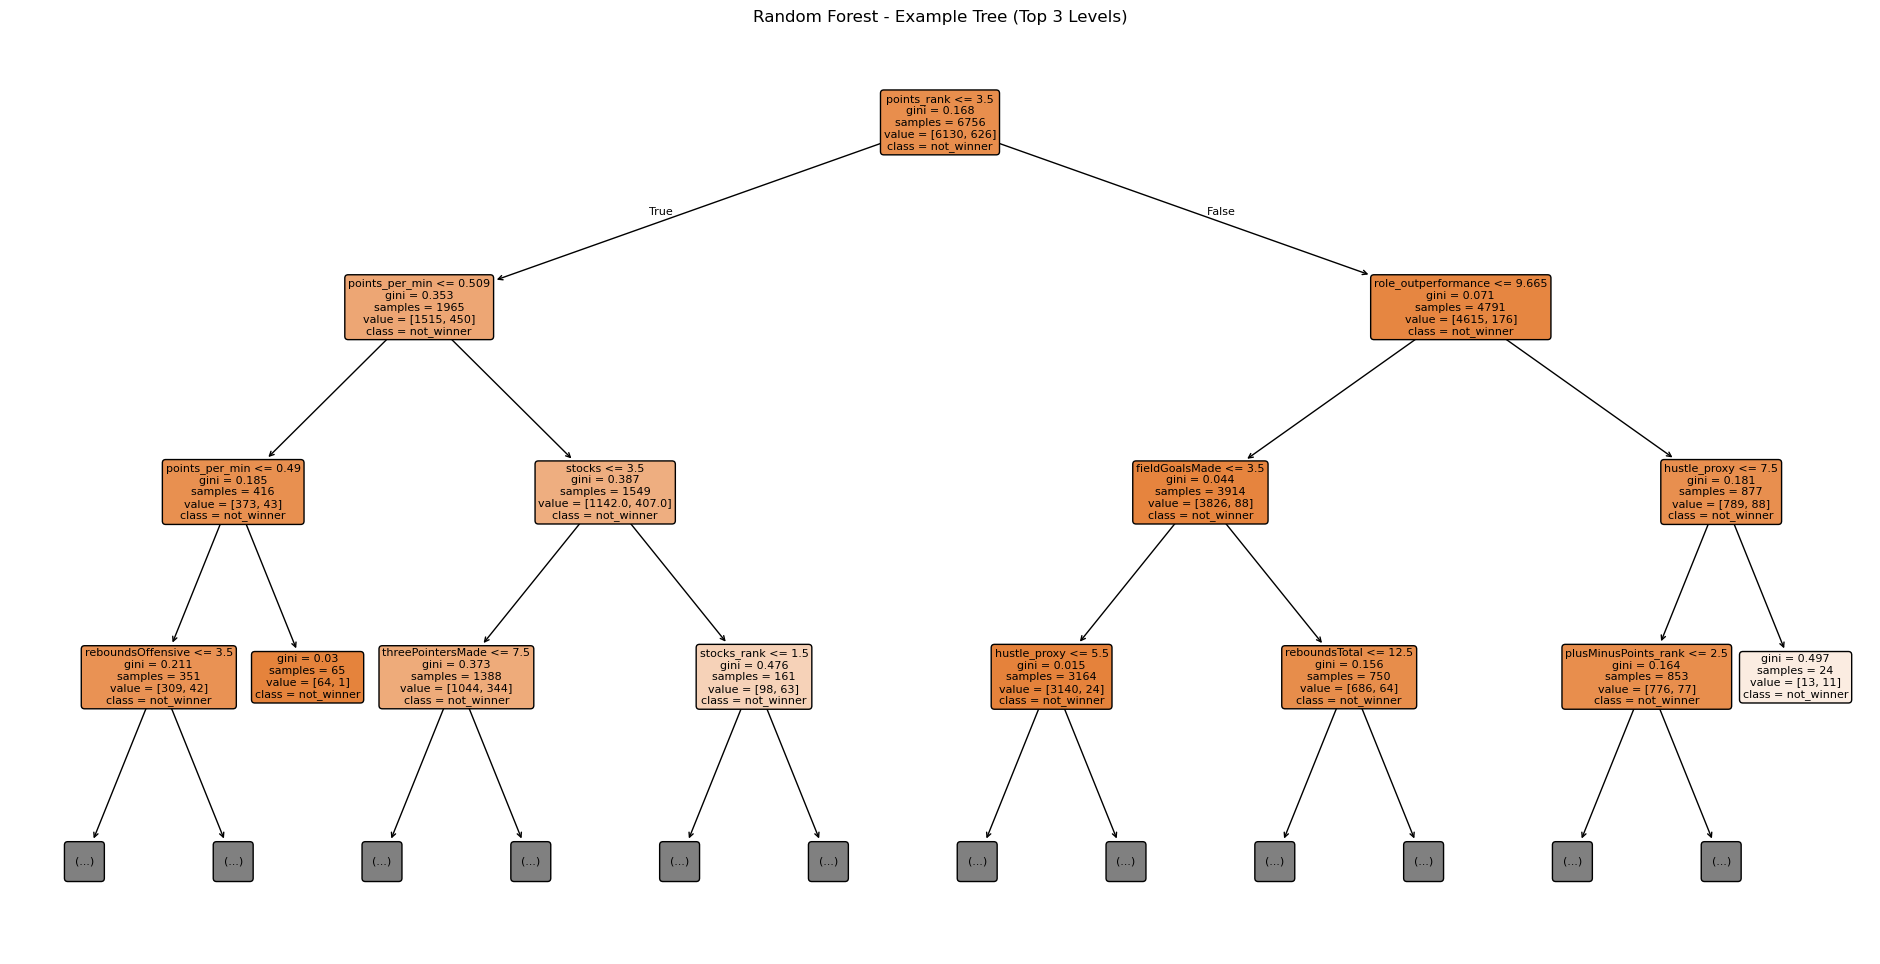

In [23]:
from sklearn import tree
import matplotlib.pyplot as plt

# Visualize one tree from the random forest (first estimator).
# Limiting depth keeps the plot readable.
one_tree = model.estimators_[0]

plt.figure(figsize=(24, 12))
tree.plot_tree(
    one_tree,
    feature_names=numeric_feature_cols,
    class_names=["not_winner", "winner"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
)
plt.title("Random Forest - Example Tree (Top 3 Levels)")
plt.show()